# Sentiment Analysis on IMDb Movie Reviews
### Binary Text Classification using RNN & LSTM Models





---
##   Install & Import Dependencies




In [ ]:
# Install gensim for Word2Vec (pretrained embeddings used in Model 3)
!pip install gensim --quiet
!pip install contractions --quiet  # Handles contractions like "don't" → "do not"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Standard Libraries
import os
import zipfile
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import contractions
import gradio as gr
from collections import Counter
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# NLP & Text Processing
import contractions
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Deep Learning (Keras / TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, Bidirectional, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import callbacks
from tensorflow.keras.models import load_model

#  Word2Vec (Pretrained Embeddings)
import gensim.downloader as gensim_api      # Downloads pretrained Word2Vec

#  Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

#  Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#  Plot Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   NumPy version      : {np.__version__}")
print(f"   Pandas version     : {pd.__version__}")


All libraries imported successfully!
   TensorFlow version : 2.20.0
   NumPy version      : 2.0.2
   Pandas version     : 2.2.2


---
## Load the Dataset




In [ ]:
#  Define ZIP File Path
ZIP_PATH = '/content/drive/MyDrive/AI Coursework/movie_review.zip'

# ── Extract ZIP File
EXTRACT_PATH = '/content/movie_review_dataset'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!\n")

# Optional: Check extracted files
print("Extracted files:")
print(os.listdir(EXTRACT_PATH))

Dataset extracted successfully!

Extracted files:
['__MACOSX', '5. Movie Review Dataset']


In [ ]:
# Load dataset files
train_path = '/content/movie_review_dataset/5. Movie Review Dataset/train_movie_review.csv'
val_path   = '/content/movie_review_dataset/5. Movie Review Dataset/val_movie_review.csv'
test_path  = '/content/movie_review_dataset/5. Movie Review Dataset/test_movie_review.csv'

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

# Remove unwanted column if it exists
for df in [df_train, df_val, df_test]:
    if 'Unnamed: 0' in df.columns:
        df.drop('Unnamed: 0', axis=1, inplace=True)

# Print dataset shapes
print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

# Print sentiment counts
print("\nTrain sentiment counts:")
print(df_train['sentiment'].value_counts())

# Print one sample review
print("\nSample review:\n")
print(df_train['review'].iloc[0][:400], "...")

Train shape: (35000, 2)
Validation shape: (5000, 2)
Test shape: (10000, 2)

Train sentiment counts:
sentiment
0    17584
1    17416
Name: count, dtype: int64

Sample review:

Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terrible. The stage show looks like a bit of a musical, but this races along with songs hurriedly following ...


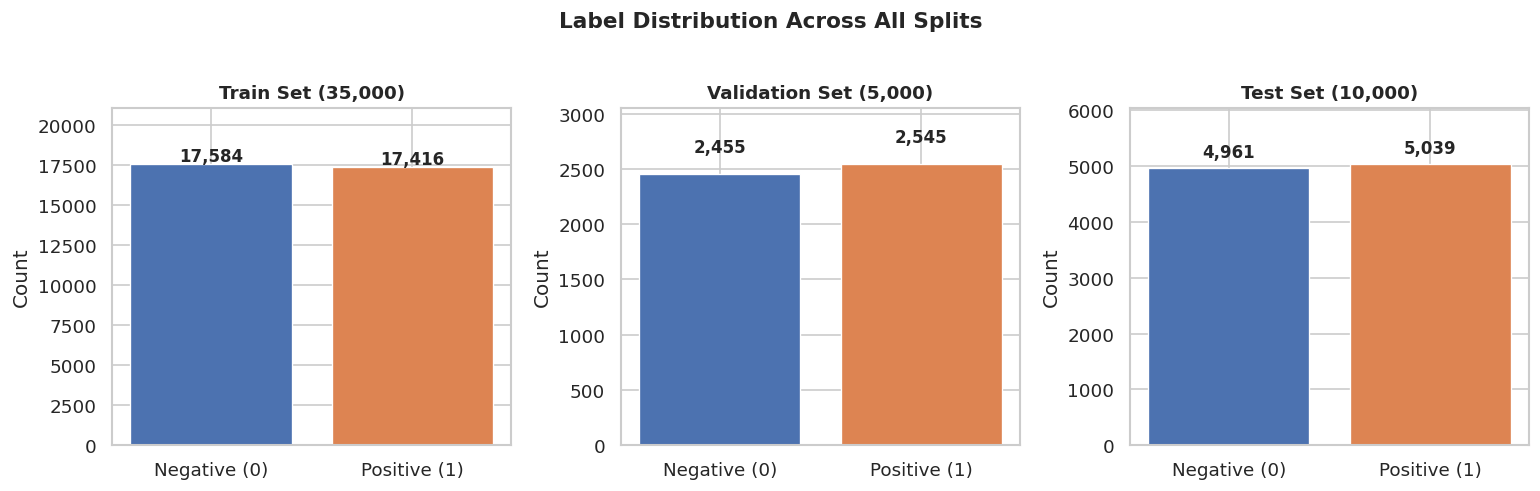

Dataset is well-balanced — equal positive and negative reviews.


In [ ]:
# Visualize label distribution (sanity check)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
splits     = [df_train, df_val, df_test]
titles     = ['Train Set (35,000)', 'Validation Set (5,000)', 'Test Set (10,000)']
colors     = [['#4C72B0', '#DD8452'], ['#4C72B0', '#DD8452'], ['#4C72B0', '#DD8452']]

for ax, df, title, color in zip(axes, splits, titles, colors):
    counts = df['sentiment'].value_counts().sort_index()
    bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
                  color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Label Distribution Across All Splits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('label_distribution.png', bbox_inches='tight')
plt.show()
print("Dataset is well-balanced — equal positive and negative reviews.")


---
## Text Preprocessing




In [ ]:
#  Initialize NLP tools
lemmatizer = WordNetLemmatizer()
STOPWORDS  = set(stopwords.words('english'))

NEGATIONS = {'no', 'not', 'nor', 'never', 'neither', 'nobody',
             'nothing', 'nowhere', 'hardly', 'scarcely', 'barely'}
STOPWORDS -= NEGATIONS  # Keep negations

def clean_text(text):

    # Step 1: Expand contractions (e.g. "don't" → "do not")
    text = contractions.fix(text)

    # Step 2: Lowercase everything
    text = text.lower()

    # Step 3: Remove HTML tags (IMDb reviews often contain <br />)
    text = re.sub(r'<[^>]+>', ' ', text)

    # Step 4: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 5: Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 6: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 7: Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 8: Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 9: Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOPWORDS and len(w) > 1]

    return ' '.join(tokens)

#  Quick test on a sample review
sample = df_train['review'].iloc[0]
print("BEFORE:", sample[:200])
print()
print("AFTER :", clean_text(sample)[:200])


BEFORE: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -

AFTER : avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical rac


In [ ]:
#  Apply cleaning to all splits

print("Cleaning training set   (35,000 reviews)...")
df_train['cleaned'] = df_train['review'].apply(clean_text)

print("Cleaning validation set (5,000 reviews)...")
df_val['cleaned']   = df_val['review'].apply(clean_text)

print("Cleaning test set       (10,000 reviews)...")
df_test['cleaned']  = df_test['review'].apply(clean_text)

print("\nCleaning complete!")
print(f"Sample cleaned review: {df_train['cleaned'].iloc[1][:200]}...")


Cleaning training set   (35,000 reviews)...
Cleaning validation set (5,000 reviews)...
Cleaning test set       (10,000 reviews)...

Cleaning complete!
Sample cleaned review: movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre...


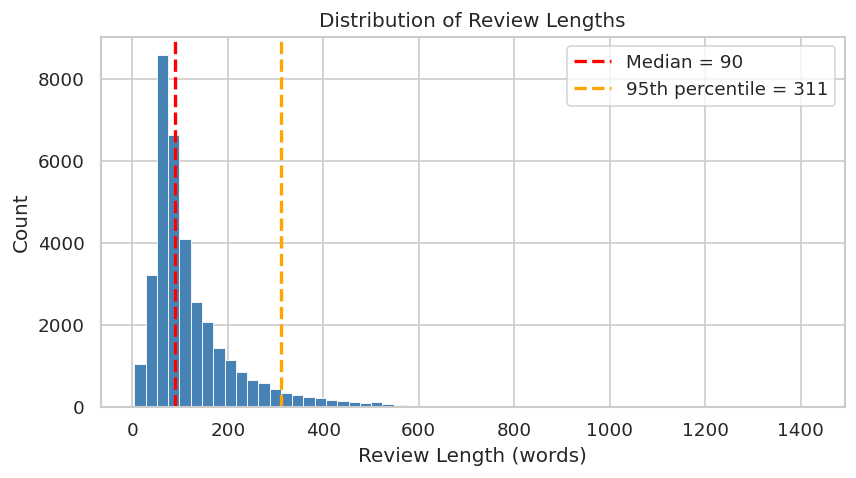

In [ ]:
#  Review length analysis after cleaning
train_lengths = df_train['cleaned'].str.split().apply(len)

#  Histogram of review lengths
plt.figure(figsize=(8, 4))

plt.hist(train_lengths, bins=60,
         color='steelblue',
         edgecolor='white',
         linewidth=0.5)

plt.axvline(train_lengths.median(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Median = {train_lengths.median():.0f}')

plt.axvline(np.percentile(train_lengths, 95),
            color='orange',
            linestyle='--',
            linewidth=2,
            label=f'95th percentile = {np.percentile(train_lengths, 95):.0f}')

plt.xlabel('Review Length (words)')
plt.ylabel('Count')
plt.title('Distribution of Review Lengths')
plt.legend()

plt.show()

<Figure size 720x480 with 0 Axes>

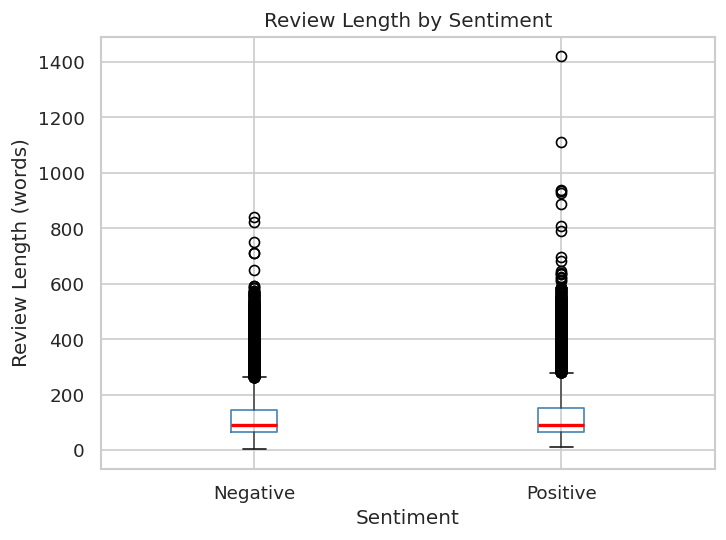

Review Length Statistics:

count    35000.0
mean       120.8
std         90.9
min          4.0
25%         65.0
50%         90.0
75%        147.0
max       1421.0
Name: cleaned, dtype: float64

95th percentile: 311.0 words

We can use this value as MAX_LEN for padding.


In [ ]:
#  Box plot of review lengths by sentiment
df_plot = pd.DataFrame({
    'Length': train_lengths,
    'Sentiment': df_train['sentiment'].map({0:'Negative', 1:'Positive'})
})

plt.figure(figsize=(6, 4))

df_plot.boxplot(column='Length',
                by='Sentiment',
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))

plt.xlabel('Sentiment')
plt.ylabel('Review Length (words)')
plt.title('Review Length by Sentiment')

plt.suptitle('')
plt.show()

#  Print statistics
print("Review Length Statistics:\n")
print(train_lengths.describe().round(1))

print("\n95th percentile:",
      round(np.percentile(train_lengths, 95), 0),
      "words")

print("\nWe can use this value as MAX_LEN for padding.")

---
## Data Visualization usin Word Cloud & Top Words




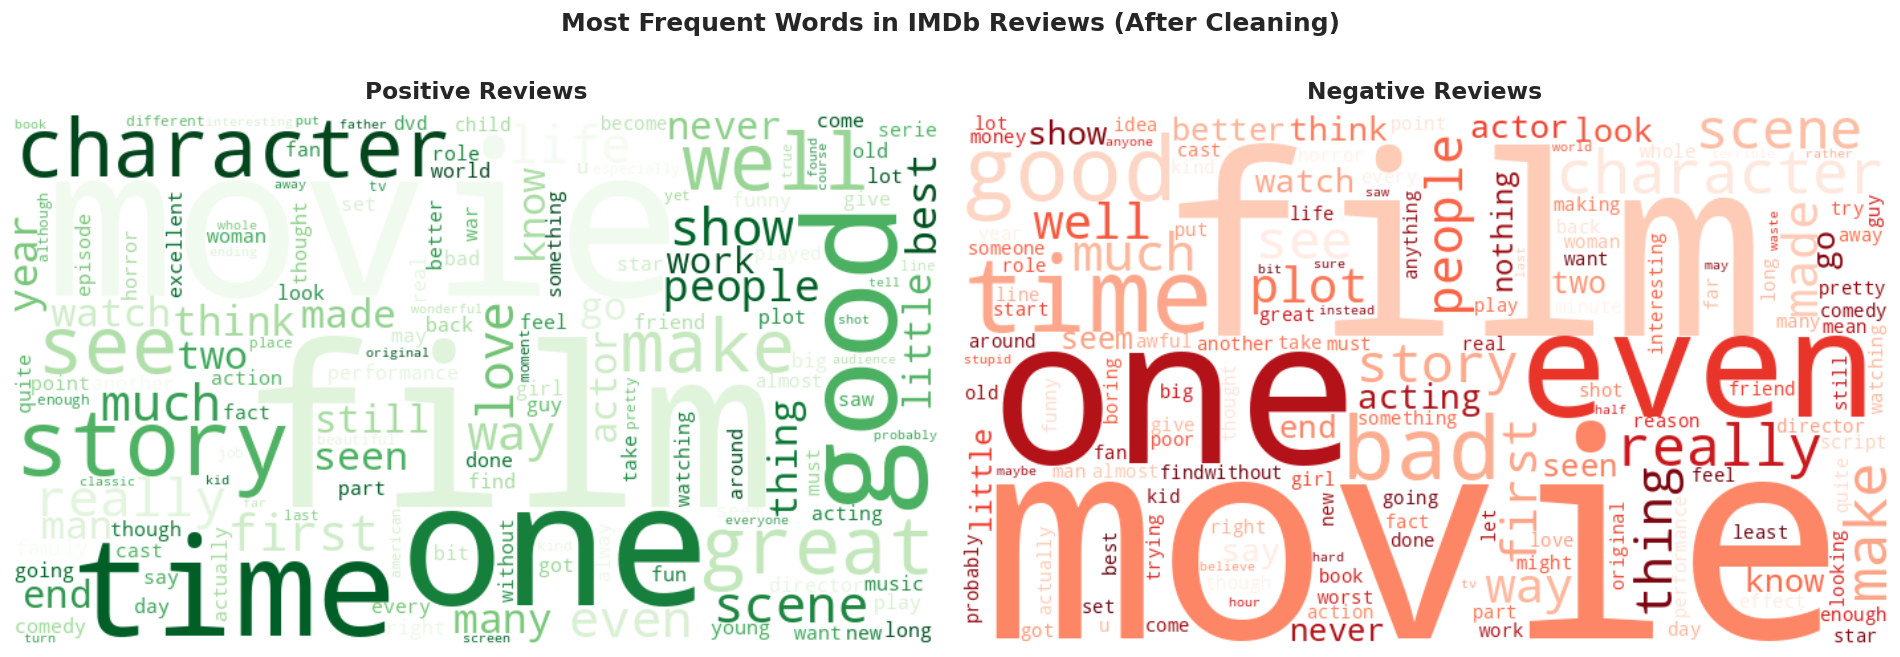

In [ ]:
#  Build word clouds for positive and negative reviews
pos_text = ' '.join(df_train[df_train['sentiment'] == 1]['cleaned'])
neg_text = ' '.join(df_train[df_train['sentiment'] == 0]['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, text, title, cmap in zip(
    axes,
    [pos_text, neg_text],
    ['Positive Reviews', 'Negative Reviews'],
    ['Greens', 'Reds']
):
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        max_words=150,
        colormap=cmap,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

fig.suptitle('Most Frequent Words in IMDb Reviews (After Cleaning)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()


---
##  Tokenization & Sequence Padding




In [ ]:
#  Hyperparameters

VOCAB_SIZE  = 30_000
MAX_LEN     = 300
EMBED_DIM   = 128       # Size of the trainable embedding vector
OOV_TOKEN   = '<OOV>'

print(f"Configuration:")
print(f"Vocabulary : {VOCAB_SIZE:,}")
print(f"Max sequence len: {MAX_LEN}")
print(f"Embedding dim: {EMBED_DIM}")


Configuration:
Vocabulary : 30,000
Max sequence len: 300
Embedding dim: 128


In [ ]:
#  Fit Keras Tokenizer on TRAINING data only

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df_train['cleaned'])

vocab_size_actual = len(tokenizer.word_index) + 1
print(f"Total unique words found : {vocab_size_actual:,}")
print(f"(We will use top {VOCAB_SIZE:,} words)")
print(f"\nSample word: index mappings:")
sample_words = list(tokenizer.word_index.items())[:10]
for word, idx in sample_words:
    print(f"'{word}' : {idx}")


Total unique words found : 77,133
(We will use top 30,000 words)

Sample word: index mappings:
'<OOV>' : 1
'not' : 2
'movie' : 3
'film' : 4
'one' : 5
'like' : 6
'time' : 7
'would' : 8
'good' : 9
'character' : 10


In [ ]:
#  Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(df_train['cleaned'])
X_val_seq   = tokenizer.texts_to_sequences(df_val['cleaned'])
X_test_seq  = tokenizer.texts_to_sequences(df_test['cleaned'])

print("Example sequence (first review, first 15 tokens):")
print(X_train_seq[0][:15])


Example sequence (first review, first 15 tokens):
[3943, 214, 3, 316, 2421, 161, 209, 15676, 35, 2, 398, 20, 499, 172, 14]


In [ ]:
#  Apply padding
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Extract labels
y_train = df_train['sentiment'].values
y_val   = df_val['sentiment'].values
y_test  = df_test['sentiment'].values

print("Padding complete!")
print(f"X_train shape : {X_train.shape} : (35000 reviews × 300 tokens each)")
print(f"X_val shape : {X_val.shape}")
print(f"X_test shape : {X_test.shape}")
print()
print("Padded sequence example (last 10 values, zeros = padding):")
print(X_train[0][-10:])


Padding complete!
X_train shape : (35000, 300) : (35000 reviews × 300 tokens each)
X_val shape : (5000, 300)
X_test shape : (10000, 300)

Padded sequence example (last 10 values, zeros = padding):
[0 0 0 0 0 0 0 0 0 0]


---
##  Model Architecture




In [ ]:
#  Training Hyperparameters
BATCH_SIZE = 128
EPOCHS= 15
LR= 1e-3   # Learning rate for Adam optimizer


###  Model 1 — Simple RNN with Trainable Embedding



In [ ]:
def build_rnn_model(vocab_size, embed_dim, max_len):


    model = Sequential([
        #Explicit input layer so model is properly built
        tf.keras.layers.Input(shape=(max_len,)),

        # Embedding layer
        Embedding(input_dim=vocab_size, output_dim=embed_dim),

        # SimpleRNN layer
        SimpleRNN(64, dropout=0.2),

        # Dropout
        Dropout(0.3),

        # Dense hidden layer
        Dense(32, activation='relu'),
        Dropout(0.2),

        # Output layer
        Dense(1, activation='sigmoid')
    ], name='SimpleRNN_Model')

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build and summarize
model1 = build_rnn_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,854,465 (14.70 MB)

 Trainable params: 3,854,465 (14.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
model1_callbacks = [
    callbacks.EarlyStopping(
        monitor= 'val_loss',
        patience= 3,
        restore_best_weights = True,
        verbose= 1
    ),
    callbacks.ReduceLROnPlateau(
        monitor= 'val_loss',
        factor= 0.5,
        patience = 2,
        verbose  = 1,
        min_lr= 1e-6
    ),
    ModelCheckpoint(
        filepath= 'best_rnn_model1.keras',
        monitor= 'val_accuracy',
        save_best_only = True,
        verbose= 0
    )
]

In [ ]:
#  Train Model 1
print("Training Model 1: Simple RNN...")
history1 = model1.fit(
    X_train, y_train,
    epochs= EPOCHS,
    batch_size= BATCH_SIZE,
    validation_data = (X_val, y_val),
    callbacks= model1_callbacks,
    verbose= 1
)
print("\nModel 1 training complete!")


Training Model 1: Simple RNN...
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5177 - loss: 0.6916 - val_accuracy: 0.4972 - val_loss: 0.6930 - learning_rate: 5.0000e-04
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5243 - loss: 0.6829 - val_accuracy: 0.4986 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 3/15
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5313 - loss: 0.6708
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5305 - loss: 0.6679 - val_accuracy: 0.4932 - val_loss: 0.7020 - learning_rate: 5.0000e-04
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5300 - loss: 0.6569 - val_accuracy: 0.4968 - val_loss: 0.7062 - learning_rate: 2.5000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Model 1 training complete!


In [ ]:
#  Test Evaluation: Model 1 (Simple RNN)
loss1, acc1 = model1.evaluate(X_test, y_test, batch_size=256, verbose=0)
print(f"Model 1 — Simple RNN")
print(f"  Test Accuracy : {acc1*100:.2f}%")
print(f"  Test Loss     : {loss1:.4f}")


Model 1 — Simple RNN
  Test Accuracy : 50.00%
  Test Loss     : 0.6932


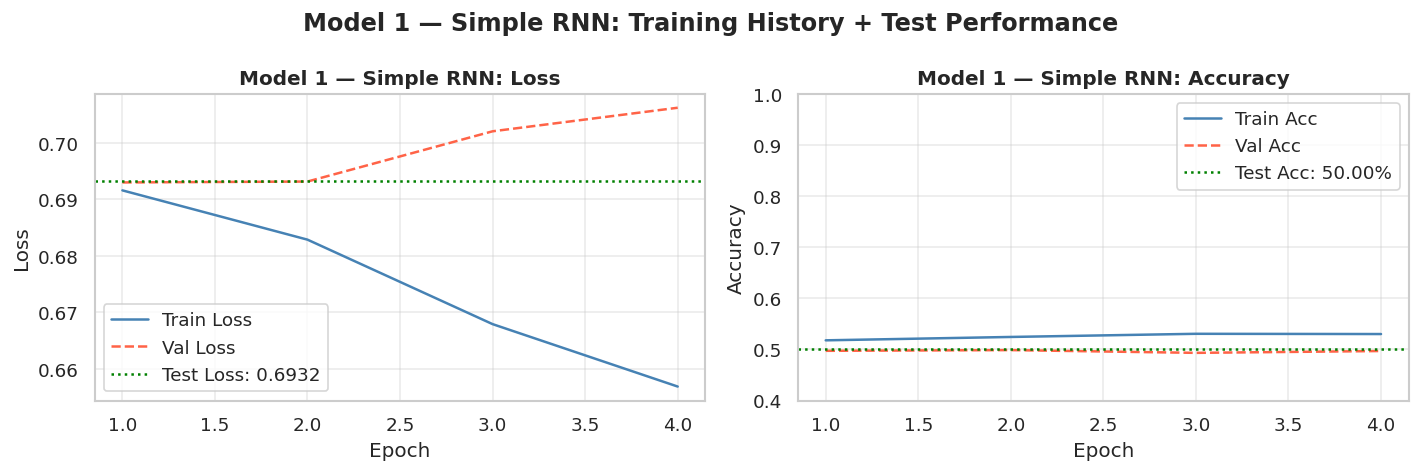

In [ ]:
# Plot training curves
epochs1 = range(1, len(history1.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs1, history1.history['loss'],     label='Train Loss',     color='steelblue')
axes[0].plot(epochs1, history1.history['val_loss'], label='Val Loss',       color='tomato', linestyle='--')
axes[0].axhline(y=loss1, color='green', linestyle=':', linewidth=1.5,       label=f'Test Loss: {loss1:.4f}')
axes[0].set_title('Model 1 — Simple RNN: Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs1, history1.history['accuracy'],     label='Train Acc',  color='steelblue')
axes[1].plot(epochs1, history1.history['val_accuracy'], label='Val Acc',    color='tomato', linestyle='--')
axes[1].axhline(y=acc1, color='green', linestyle=':', linewidth=1.5,        label=f'Test Acc: {acc1*100:.2f}%')
axes[1].set_title('Model 1 — Simple RNN: Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Model 1 — Simple RNN: Training History + Test Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('model1_evaluation.png', bbox_inches='tight')
plt.show()

###  Model 2 — LSTM with Trainable Embedding




In [ ]:
def build_lstm_model(vocab_size, embed_dim, max_len):

    model = Sequential([

        # Input layer
        tf.keras.layers.Input(shape=(max_len,)),

        # Embedding layer
        Embedding(input_dim=vocab_size, output_dim=embed_dim),

        # First LSTM layer
        # Removed recurrent_dropout for faster GPU training
        LSTM(128,
             return_sequences=True,
             dropout=0.2),

        # Second LSTM layer
        LSTM(64,
             dropout=0.2),

        # Dropout
        Dropout(0.3),

        # Dense layer
        Dense(32, activation='relu'),
        Dropout(0.2),

        # Output layer
        Dense(1, activation='sigmoid')
    ], name='LSTM_Trainable_Embedding')

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# Build model
model2 = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)

# Show summary
model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 300, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,023,105 (15.35 MB)

 Trainable params: 4,023,105 (15.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Callbacks for Model 2 (LSTM)
model2_callbacks = [
    callbacks.EarlyStopping(
        monitor= 'val_loss',
        patience= 3,
        restore_best_weights = True,
        verbose= 1
    ),
    callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        verbose  = 1,
        min_lr   = 1e-6
    ),
    ModelCheckpoint(
        filepath= 'best_lstm_model2.keras',
        monitor= 'val_accuracy',
        save_best_only = True,
        verbose= 0
    )
]

In [ ]:
#  Train Model 2
print("Training Model 2: LSTM with Trainable Embedding...")
history2 = model2.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_val, y_val),
    callbacks       = model2_callbacks,
    verbose         = 1
)
print("\nModel 2 training complete!")


Training Model 2: LSTM with Trainable Embedding...
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5274 - loss: 0.6795 - val_accuracy: 0.5038 - val_loss: 0.6903 - learning_rate: 5.0000e-04
Epoch 2/15
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5198 - loss: 0.6769
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.5272 - loss: 0.6704 - val_accuracy: 0.5060 - val_loss: 0.7026 - learning_rate: 5.0000e-04
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.5478 - loss: 0.6548 - val_accuracy: 0.7334 - val_loss: 0.5884 - learning_rate: 2.5000e-04
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7715 - loss: 0.5270 - val_accuracy: 0.8016 - val_loss: 0.4941 - learning_rate: 2.5000e-04
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.8341 - loss: 0.4420 - val_accuracy: 0.8190 - val_loss: 0.4524 - learning_rate: 2.5000e-04
Epoch 6

In [ ]:
#  Test Evaluation: Model 2)
loss2, acc2 = model2.evaluate(X_test, y_test, batch_size=256, verbose=0)
print(f"Model 2 — LSTM Model")
print(f"Test Accuracy : {acc2*100:.2f}%")
print(f"Test Loss: {loss2:.4f}")


Model 2 — LSTM Model
Test Accuracy : 86.96%
Test Loss: 0.3855


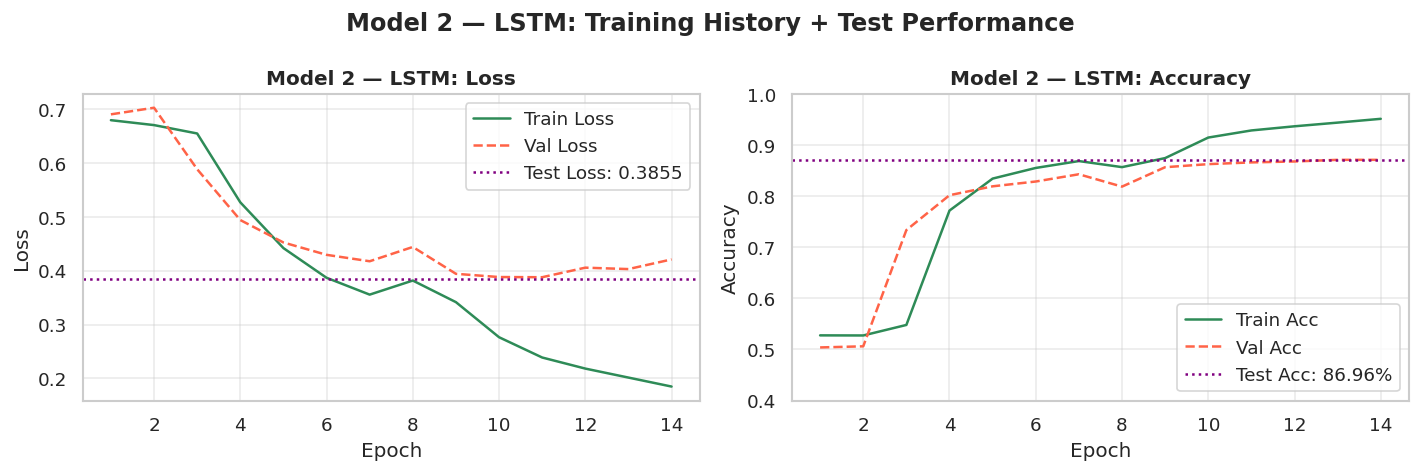

In [ ]:
# Plot training curves — Model 2 (LSTM)
epochs2 = range(1, len(history2.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs2, history2.history['loss'],     label='Train Loss',  color='seagreen')
axes[0].plot(epochs2, history2.history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
axes[0].axhline(y=loss2, color='purple', linestyle=':', linewidth=1.5,   label=f'Test Loss: {loss2:.4f}')
axes[0].set_title('Model 2 — LSTM: Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs2, history2.history['accuracy'],     label='Train Acc', color='seagreen')
axes[1].plot(epochs2, history2.history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
axes[1].axhline(y=acc2, color='purple', linestyle=':', linewidth=1.5,      label=f'Test Acc: {acc2*100:.2f}%')
axes[1].set_title('Model 2 — LSTM: Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Model 2 — LSTM: Training History + Test Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('model2_evaluation.png', bbox_inches='tight')
plt.show()

###  Model 3 — LSTM with Pretrained Word2Vec Embeddings



In [ ]:
#  Load Pretrained Word2Vec from Gensim
print("Loading pretrained Word2Vec (Google News, 300d)...")
print("This may take 2-5 minutes on first run...")

w2v_model = gensim_api.load('word2vec-google-news-300')
W2V_DIM = 300   # Google News Word2Vec produces 300-dimensional vectors

print(f"\nWord2Vec loaded!")
print(f"Vocabulary size : {len(w2v_model.key_to_index):,} words")
print(f"Vector dimension: {W2V_DIM}")
print()
# Quick test — semantic similarity
print("Semantic test — 'excellent' similar to:")
print("  ", [w for w, _ in w2v_model.most_similar('excellent', topn=5)])


Loading pretrained Word2Vec (Google News, 300d)...
This may take 2-5 minutes on first run...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Word2Vec loaded!
Vocabulary size : 3,000,000 words
Vector dimension: 300

Semantic test — 'excellent' similar to:
   ['terrific', 'superb', 'exceptional', 'fantastic', 'good']


In [ ]:
#  Build the Embedding Matrix
# Row i = the Word2Vec vector for the word at index i in our tokenizer vocabulary
# If a word is not in Word2Vec, we leave its row as zeros (random noise)

print("Building embedding matrix...")

embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found_count = 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue   # Skip words beyond our vocabulary limit
    if word in w2v_model.key_to_index:
        embedding_matrix[idx] = w2v_model[word]
        found_count += 1

coverage = (found_count / min(VOCAB_SIZE, len(tokenizer.word_index))) * 100
print(f"Words matched to Word2Vec: {found_count:,} / {VOCAB_SIZE:,}")
print(f"Coverage: {coverage:.1f}%")
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Building embedding matrix...
Words matched to Word2Vec: 24,596 / 30,000
Coverage: 82.0%
Embedding matrix shape: (30000, 300)


In [ ]:
def build_lstm_w2v_model(vocab_size, w2v_dim, max_len, embedding_matrix):

    model = Sequential([

        # Explicit input layer
        Input(shape=(max_len,)),

        # Pretrained Word2Vec embedding
        Embedding(
            input_dim=vocab_size,
            output_dim=w2v_dim,
            weights=[embedding_matrix],
            trainable=True
        ),

        # LSTM layers
        LSTM(128, return_sequences=True, dropout=0.2),
        LSTM(64, dropout=0.2),

        # Dense layers
        Dropout(0.3),
        Dense(32, activation='relu'),

        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model3 = build_lstm_w2v_model(
    VOCAB_SIZE,
    W2V_DIM,
    MAX_LEN,
    embedding_matrix
)

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 300, 300)       │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 300, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,271,169 (35.37 MB)

 Trainable params: 9,271,169 (35.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for Model 3 (LSTM + Word2Vec)
model3_callbacks = [
    callbacks.EarlyStopping(
        monitor= 'val_loss',
        patience= 3,
        restore_best_weights = True,
        verbose= 1
    ),
    callbacks.ReduceLROnPlateau(
        monitor= 'val_loss',
        factor= 0.5,
        patience= 2,
        verbose= 1,
        min_lr = 1e-6
    ),
    ModelCheckpoint(
        filepath= 'best_lstm_w2v_model3.keras',
        monitor= 'val_accuracy',
        save_best_only = True,
        verbose        = 0
    )
]

In [ ]:
#  Train Model 3
print("Training Model 3: LSTM + Word2Vec...")
history3 = model3.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_val, y_val),
    callbacks       = model3_callbacks,
    verbose         = 1
)
print("\n Model 3 training complete!")


Training Model 3: LSTM + Word2Vec...
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.5029 - loss: 0.6936 - val_accuracy: 0.4974 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.5171 - loss: 0.6842 - val_accuracy: 0.5014 - val_loss: 0.6885 - learning_rate: 0.0010
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.5344 - loss: 0.6681 - val_accuracy: 0.7408 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.7836 - loss: 0.5152 - val_accuracy: 0.8404 - val_loss: 0.4010 - learning_rate: 0.0010
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.8605 - loss: 0.3722 - val_accuracy: 0.8522 - val_loss: 0.3689 - learning_rate: 0.0010
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.9035 - loss: 0.2686 - val_accuracy: 0.8762 - val_loss: 0.3045 - learning_rate: 0.0010
Epoch 7/15
274/274 ━━━━━━━━━━━━━━━━━━━━

In [ ]:

loss3, acc3 = model3.evaluate(X_test, y_test, batch_size=256, verbose=0)
print(f"Model 3 — LSTM + Word2Vec...")
print(f"Test Accuracy: {acc3*100:.2f}%")
print(f"Test Loss: {loss3:.4f}")

Model 3 — LSTM + Word2Vec...
Test Accuracy: 87.72%
Test Loss: 0.2972


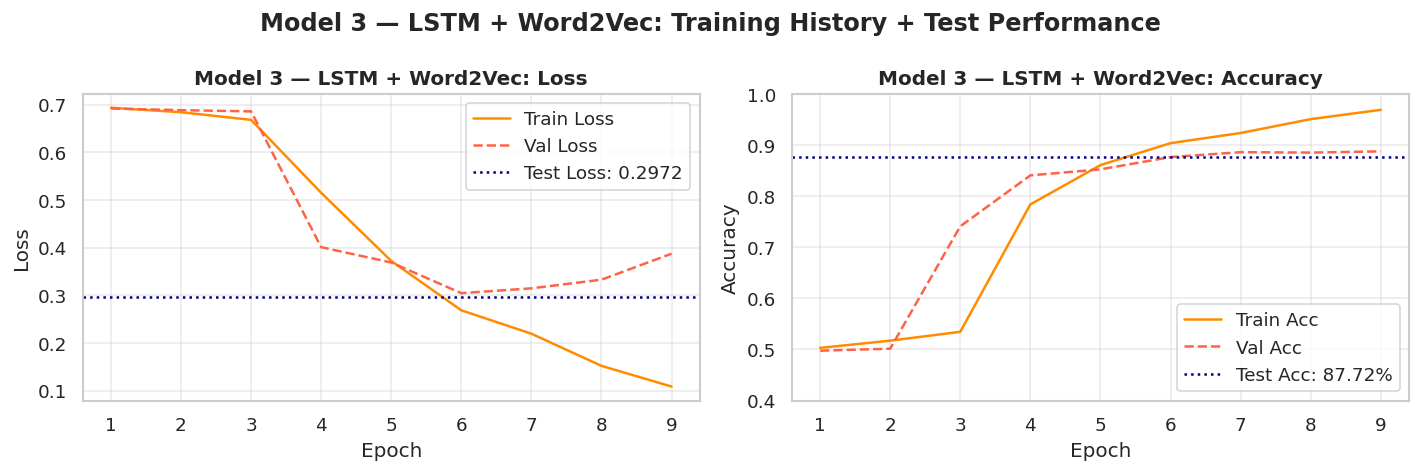

In [ ]:
# Plot training curves — Model 3 (LSTM + Word2Vec)
epochs3 = range(1, len(history3.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs3, history3.history['loss'],     label='Train Loss',  color='darkorange')
axes[0].plot(epochs3, history3.history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
axes[0].axhline(y=loss3, color='navy', linestyle=':', linewidth=1.5,     label=f'Test Loss: {loss3:.4f}')
axes[0].set_title('Model 3 — LSTM + Word2Vec: Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs3, history3.history['accuracy'],     label='Train Acc', color='darkorange')
axes[1].plot(epochs3, history3.history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
axes[1].axhline(y=acc3, color='navy', linestyle=':', linewidth=1.5,        label=f'Test Acc: {acc3*100:.2f}%')
axes[1].set_title('Model 3 — LSTM + Word2Vec: Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Model 3 — LSTM + Word2Vec: Training History + Test Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('model3_evaluation.png', bbox_inches='tight')
plt.show()

---
## Training Curves — Loss & Accuracy

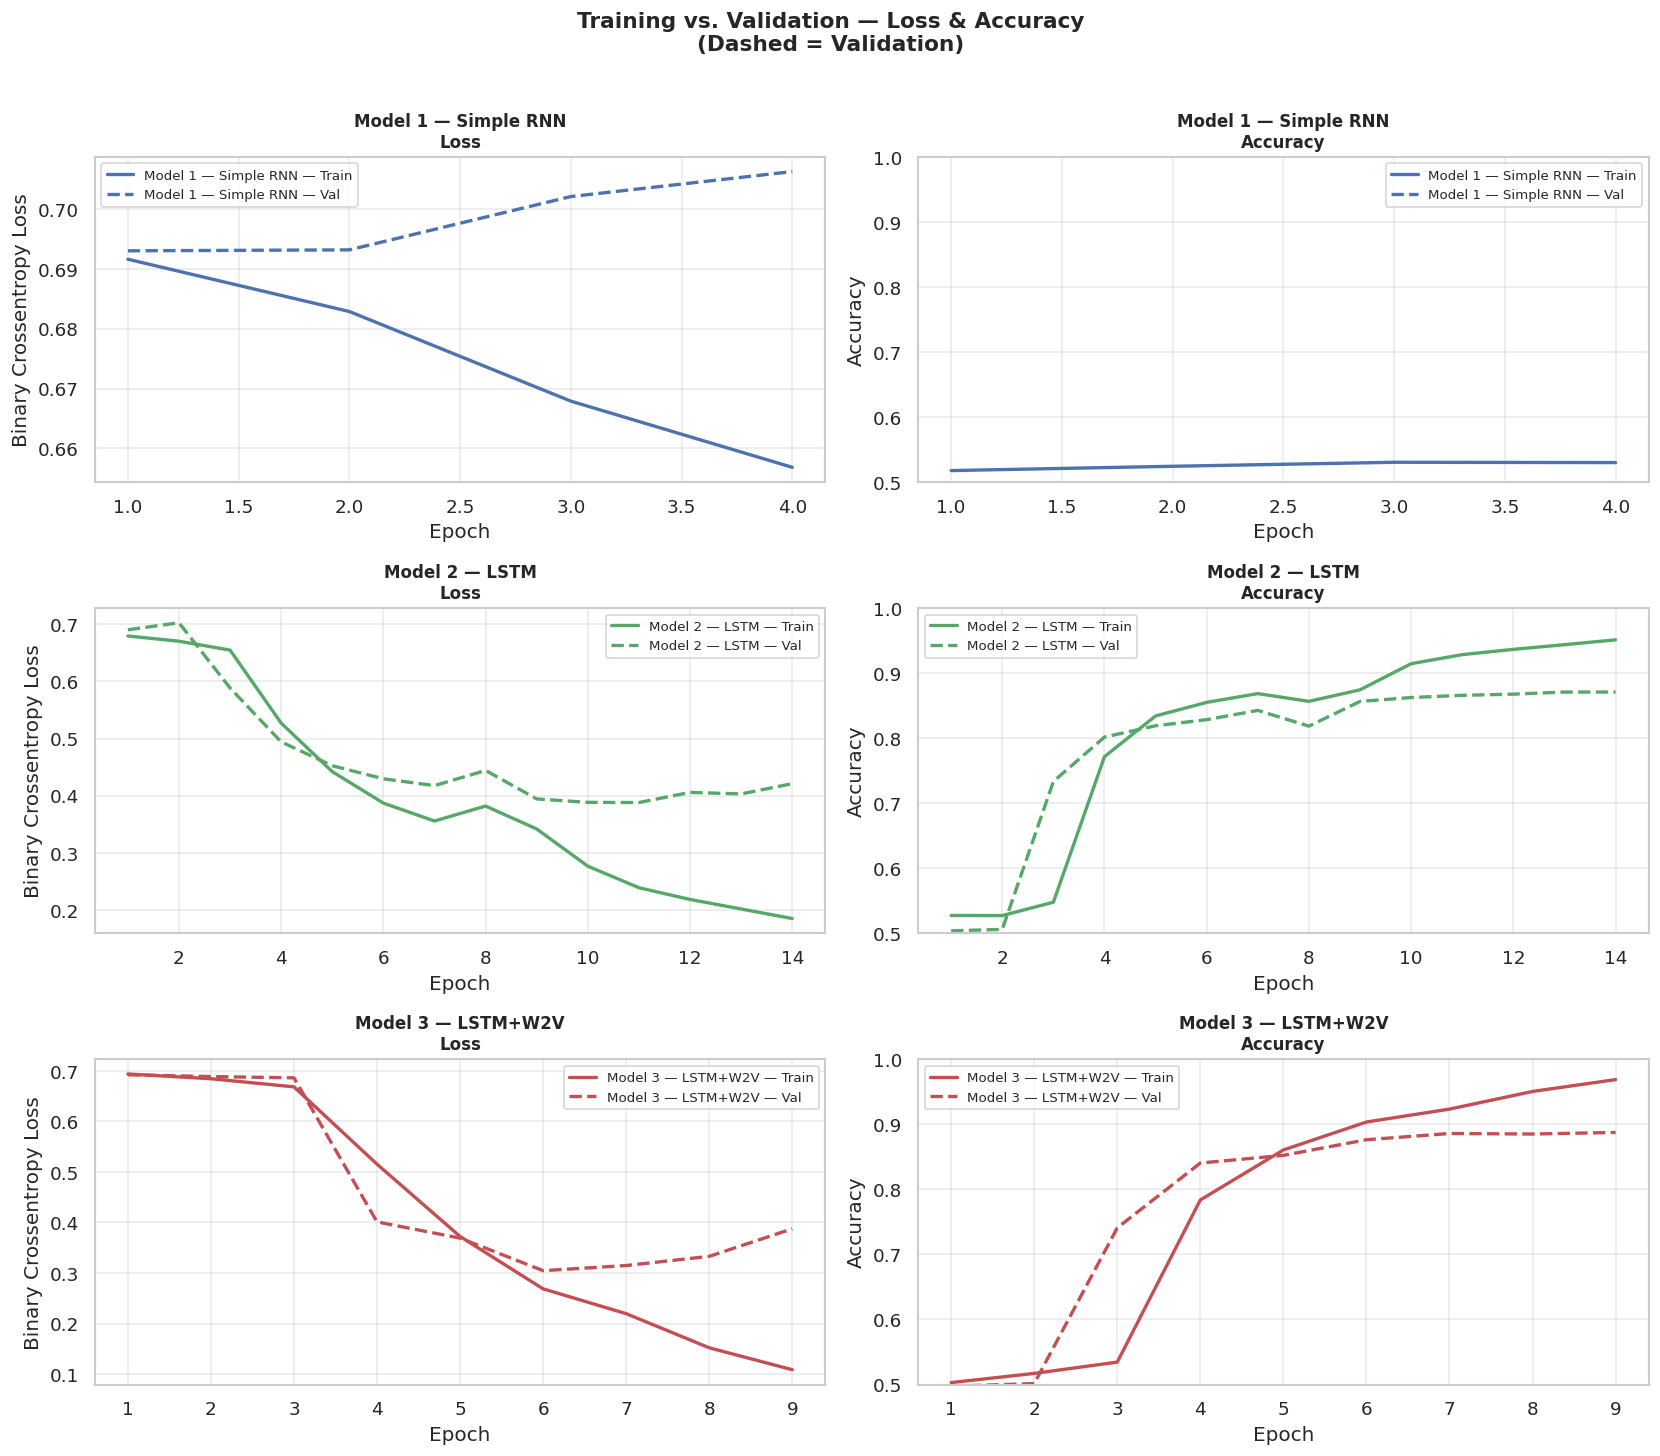

In [ ]:
def plot_training_history(history, model_name, color, ax_loss, ax_acc):
    """
    Plot loss and accuracy curves for a single model onto given axes.
    We overlay train and val curves to visually identify overfitting.
    """
    epochs_ran = range(1, len(history.history['loss']) + 1)

    #  Loss
    ax_loss.plot(epochs_ran, history.history['loss'],
                 color=color, linewidth=2, label=f'{model_name} — Train')
    ax_loss.plot(epochs_ran, history.history['val_loss'],
                 color=color, linewidth=2, linestyle='--', label=f'{model_name} — Val')
    ax_loss.set_title(f'{model_name}\nLoss', fontsize=10, fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Binary Crossentropy Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.4)

    #  Accuracy
    ax_acc.plot(epochs_ran, history.history['accuracy'],
                color=color, linewidth=2, label=f'{model_name} — Train')
    ax_acc.plot(epochs_ran, history.history['val_accuracy'],
                color=color, linewidth=2, linestyle='--', label=f'{model_name} — Val')
    ax_acc.set_title(f'{model_name}\nAccuracy', fontsize=10, fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim(0.5, 1.0)
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.4)


#  3×2 grid: one row per model
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
configs = [
    (history1, 'Model 1 — Simple RNN', '#4C72B0'),
    (history2, 'Model 2 — LSTM',       '#55A868'),
    (history3, 'Model 3 — LSTM+W2V',   '#C44E52'),
]

for i, (hist, name, color) in enumerate(configs):
    plot_training_history(hist, name, color, axes[i, 0], axes[i, 1])

fig.suptitle('Training vs. Validation — Loss & Accuracy\n(Dashed = Validation)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()


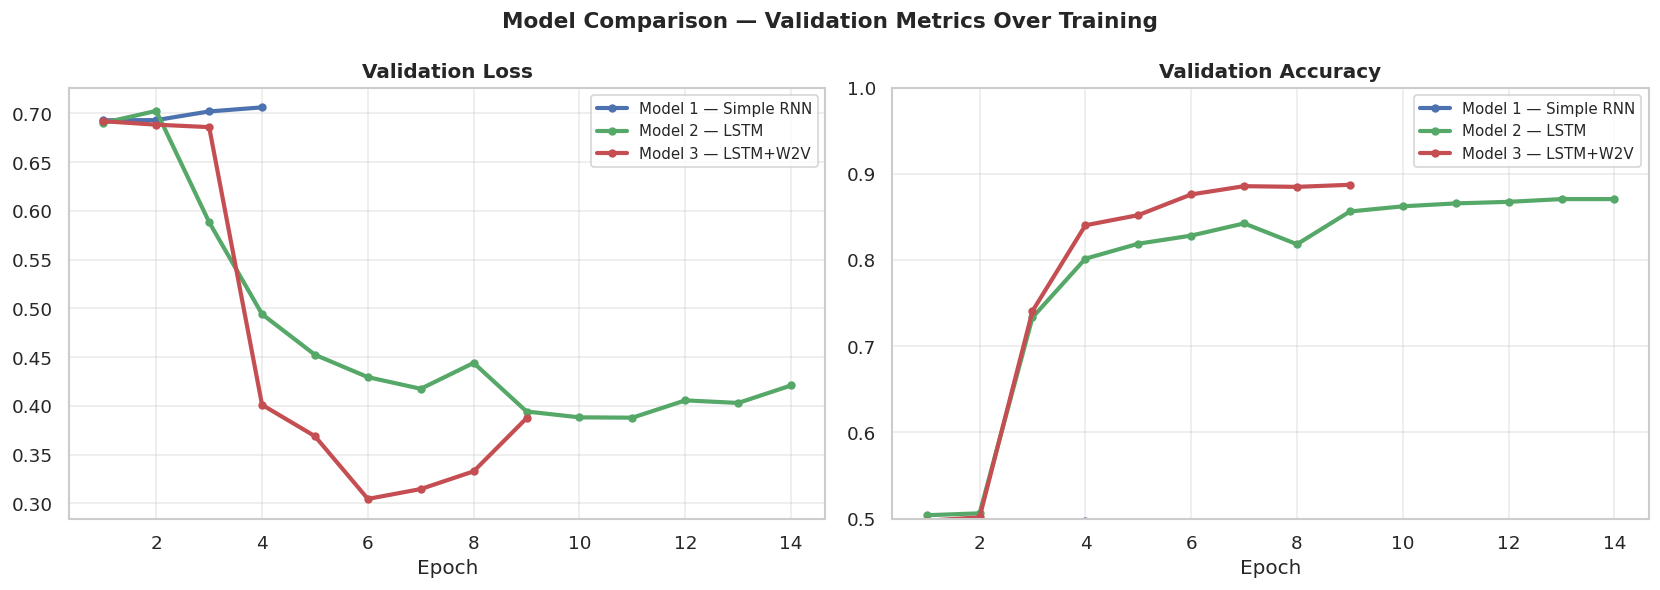

In [ ]:
#  comparison of all 3 val_accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#55A868', '#C44E52']
labels = ['Model 1 — Simple RNN', 'Model 2 — LSTM', 'Model 3 — LSTM+W2V']

for hist, label, color in zip([history1, history2, history3], labels, colors):
    epochs_ran = range(1, len(hist.history['val_loss']) + 1)
    axes[0].plot(epochs_ran, hist.history['val_loss'],
                 color=color, linewidth=2.5, marker='o', markersize=4, label=label)
    axes[1].plot(epochs_ran, hist.history['val_accuracy'],
                 color=color, linewidth=2.5, marker='o', markersize=4, label=label)

for ax, metric in zip(axes, ['Validation Loss', 'Validation Accuracy']):
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

axes[1].set_ylim(0.5, 1.0)

fig.suptitle('Model Comparison — Validation Metrics Over Training',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_curves.png', bbox_inches='tight')
plt.show()


---
##  Model Evaluation on Test Set



In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Full evaluation pipeline for one model:
    1. Predict probabilities → convert to binary labels
    2. Compute accuracy, classification report
    3. Return results dict for summary table
    """
    # Get prediction probabilities
    y_proba = model.predict(X_test, batch_size=256, verbose=0).flatten()

    # Convert probabilities → binary labels (threshold = 0.5)
    y_pred  = (y_proba >= 0.5).astype(int)

    # Compute metrics
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Negative', 'Positive'],
                                   output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print()
    print("  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Negative', 'Positive']))

    return {
        'model'    : model_name,
        'accuracy' : acc,
        'precision': report['macro avg']['precision'],
        'recall'   : report['macro avg']['recall'],
        'f1_score' : report['macro avg']['f1-score'],
        'cm'       : cm,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba
    }

#  Evaluate all three models
print("Evaluating all models on test set (10,000 reviews)...")
results1 = evaluate_model(model1, X_test, y_test, 'Model 1 — Simple RNN')
results2 = evaluate_model(model2, X_test, y_test, 'Model 2 — LSTM')
results3 = evaluate_model(model3, X_test, y_test, 'Model 3 — LSTM + Word2Vec')
all_results = [results1, results2, results3]


Evaluating all models on test set (10,000 reviews)...

  Model 1 — Simple RNN
  Test Accuracy : 0.5000 (50.00%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.96      0.66      4961
    Positive       0.54      0.05      0.09      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.37     10000
weighted avg       0.52      0.50      0.37     10000


  Model 2 — LSTM
  Test Accuracy : 0.8696 (86.96%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      4961
    Positive       0.87      0.87      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


  Model 3 — LSTM + Word2Vec
  Test Accuracy : 0.8772 (87.72%)

  Classification Report:
              precision    recall  f1-sco

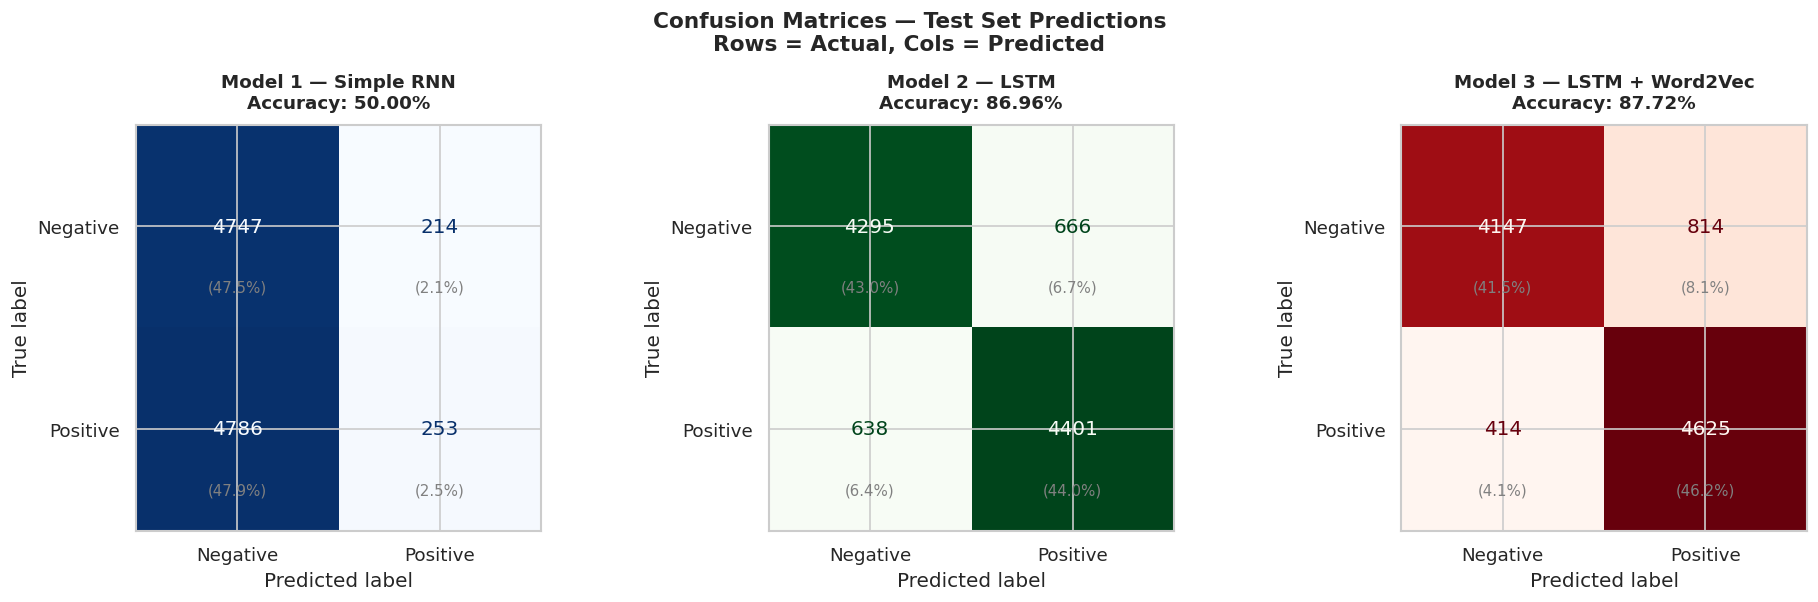

In [ ]:
#  Confusion Matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ['Blues', 'Greens', 'Reds']

for ax, result, cmap in zip(axes, all_results, cmaps):
    cm = result['cm']

    # Display confusion matrix with counts and percentages
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)

    ax.set_title(f"{result['model']}\nAccuracy: {result['accuracy']*100:.2f}%",
                 fontsize=11, fontweight='bold', pad=10)

    # Add percentage annotations below counts
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            ax.text(j, i + 0.3, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

fig.suptitle('Confusion Matrices — Test Set Predictions\n'
             'Rows = Actual, Cols = Predicted',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


In [ ]:
#  Summary Comparison Table
summary_df = pd.DataFrame([
    {
        'Model'       : r['model'],
        'Accuracy'    : f"{r['accuracy']*100:.2f}%",
        'Precision'   : f"{r['precision']:.4f}",
        'Recall'      : f"{r['recall']:.4f}",
        'F1 Score'    : f"{r['f1_score']:.4f}",
    }
    for r in all_results
])
print("\nSummary Table — All Models on Test Set:")
print(summary_df.to_string(index=False))



Summary Table — All Models on Test Set:
                    Model Accuracy Precision Recall F1 Score
     Model 1 — Simple RNN   50.00%    0.5199 0.5035   0.3735
           Model 2 — LSTM   86.96%    0.8696 0.8696   0.8696
Model 3 — LSTM + Word2Vec   87.72%    0.8798 0.8769   0.8769


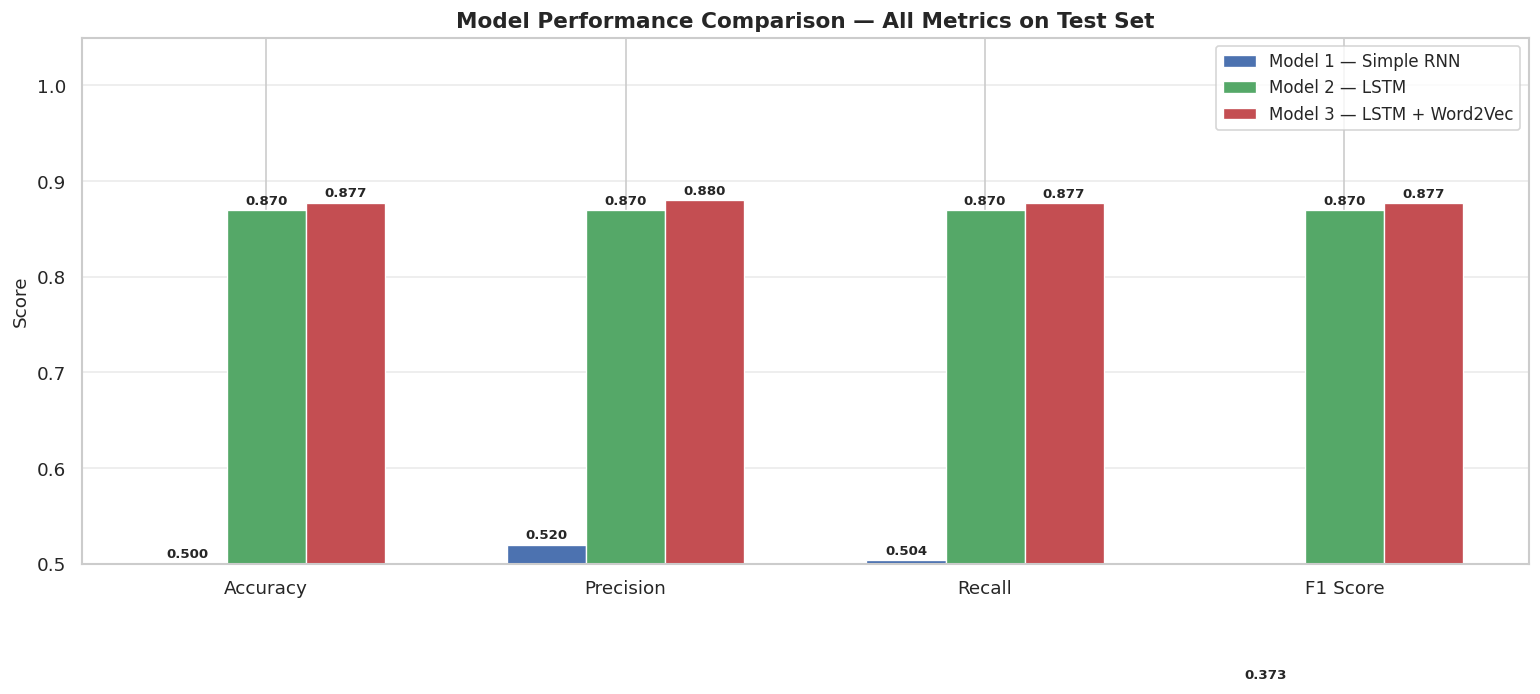

In [ ]:
#  Bar chart comparison of all metrics
metrics     = ['accuracy', 'precision', 'recall', 'f1_score']
metric_lbls = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = [r['model'] for r in all_results]
x           = np.arange(len(metrics))
width       = 0.22
colors      = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (result, color) in enumerate(zip(all_results, colors)):
    values = [result[m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=result['model'],
                  color=color, edgecolor='white', linewidth=0.8)
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metric_lbls, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison — All Metrics on Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.4)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='Random baseline')

plt.tight_layout()
plt.savefig('metric_comparison.png', bbox_inches='tight')
plt.show()


---
##  Error Analysis



In [ ]:
#  Find misclassified examples for best model (Model 3)
# We use Model 3 as it's our best performing model

y_pred3  = results3['y_pred']
y_proba3 = results3['y_proba']

# Get indices of wrong predictions
wrong_mask    = y_pred3 != y_test
wrong_indices = np.where(wrong_mask)[0]

print(f"Total misclassified by Model 3: {wrong_mask.sum():,} / {len(y_test):,}")
print(f"   ({wrong_mask.mean()*100:.1f}% error rate)")

# Separate False Positives and False Negatives
fp_mask = (y_pred3 == 1) & (y_test == 0)   # Predicted positive, actually negative
fn_mask = (y_pred3 == 0) & (y_test == 1)   # Predicted negative, actually positive

print(f"\n   False Positives (predicted +, actual -): {fp_mask.sum():,}")
print(f"   False Negatives (predicted -, actual +): {fn_mask.sum():,}")


Total misclassified by Model 3: 1,228 / 10,000
   (12.3% error rate)

   False Positives (predicted +, actual -): 814
   False Negatives (predicted -, actual +): 414


In [ ]:
#  Show 3 Misclassified Examples
def show_misclassified(indices, n=3, label=''):

    # Sort by prediction confidence — most confident wrong predictions first
    confs = y_proba3[indices]
    if label == 'False Positive':
        sorted_idx = indices[np.argsort(confs)[::-1]]  # High prob = most wrong FP
    else:
        sorted_idx = indices[np.argsort(confs)]          # Low prob = most wrong FN

    for i, idx in enumerate(sorted_idx[:n]):
        true_label = 'POSITIVE' if y_test[idx] == 1 else 'NEGATIVE'
        pred_label = 'POSITIVE' if y_pred3[idx] == 1 else 'NEGATIVE'
        conf       = y_proba3[idx]
        review_raw = df_test['review'].iloc[idx]

        print(f"\n{'─'*70}")
        print(f"Example {i+1} ({label})")
        print(f"  True Label: {true_label}")
        print(f"  Predicted: {pred_label}  (confidence = {conf:.3f})")
        print(f"{'─'*70}")
        print(f"  Review (first 300 chars):")
        print(f"  \"{review_raw[:300]}...\"")

print("\nFALSE POSITIVES — Reviews the model wrongly called POSITIVE:")
fp_indices = np.where(fp_mask)[0]
show_misclassified(fp_indices, n=2, label='False Positive')

print("\n\nFALSE NEGATIVES — Reviews the model wrongly called NEGATIVE:")
fn_indices = np.where(fn_mask)[0]
show_misclassified(fn_indices, n=2, label='False Negative')



FALSE POSITIVES — Reviews the model wrongly called POSITIVE:

──────────────────────────────────────────────────────────────────────
Example 1 (False Positive)
  True Label  : NEGATIVE
  Predicted   : POSITIVE  (confidence = 0.997)
──────────────────────────────────────────────────────────────────────
  Review (first 300 chars):
  "When teenagers go on a trip in a camper van there are many clichés that you can guarantee will follow.<br /><br />1)The teenagers will be warned not to go where they are going by a crazy local. Dan Van Husen handles that with ridiculous exposition about deadly Sirens. What, who, how and why are hand..."

──────────────────────────────────────────────────────────────────────
Example 2 (False Positive)
  True Label  : NEGATIVE
  Predicted   : POSITIVE  (confidence = 0.997)
──────────────────────────────────────────────────────────────────────
  Review (first 300 chars):
  "With the exception of about 10 sublime minutes with HB Warner on the celestial train, t

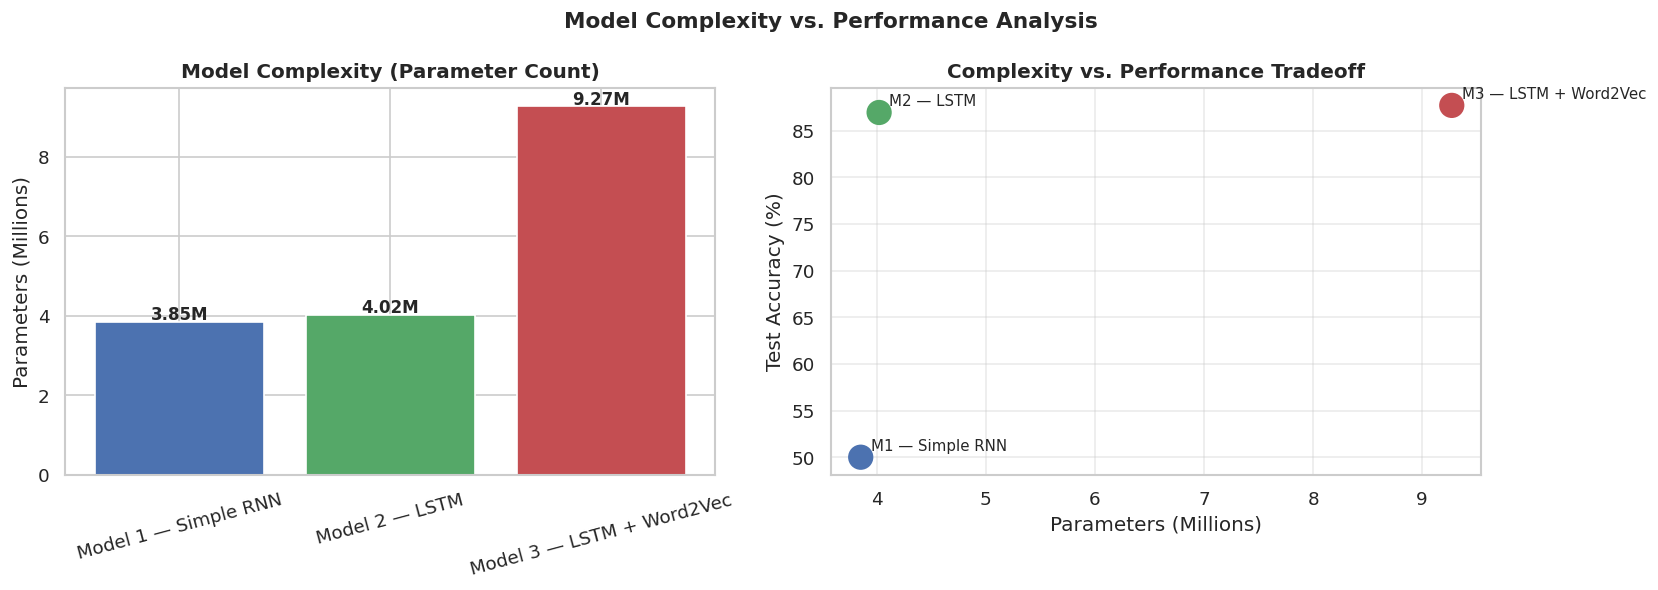


Complexity vs Performance:
  Model 1 — Simple RNN: 3.85M params → 50.00% accuracy
  Model 2 — LSTM: 4.02M params → 86.96% accuracy
  Model 3 — LSTM + Word2Vec: 9.27M params → 87.72% accuracy


In [ ]:
# ── Model Complexity vs Performance Summary ───────────────────────────────────
param_counts = {
    'Model 1 — Simple RNN'       : model1.count_params(),
    'Model 2 — LSTM'             : model2.count_params(),
    'Model 3 — LSTM + Word2Vec'  : model3.count_params(),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: parameter count
names   = list(param_counts.keys())
params  = [v / 1e6 for v in param_counts.values()]
colors  = ['#4C72B0', '#55A868', '#C44E52']
bars    = axes[0].bar(names, params, color=colors, edgecolor='white')
axes[0].set_title('Model Complexity (Parameter Count)', fontweight='bold')
axes[0].set_ylabel('Parameters (Millions)')
for bar, p in zip(bars, params):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{p:.2f}M', ha='center', fontweight='bold', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Right: accuracy vs params scatter
accs  = [results1['accuracy'], results2['accuracy'], results3['accuracy']]
axes[1].scatter(params, [a*100 for a in accs], c=colors, s=200, zorder=5)
for name, p, a in zip(names, params, accs):
    axes[1].annotate(name.replace('Model ', 'M'), (p, a*100),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_xlabel('Parameters (Millions)')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Complexity vs. Performance Tradeoff', fontweight='bold')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Model Complexity vs. Performance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('complexity_vs_performance.png', bbox_inches='tight')
plt.show()

print("\nComplexity vs Performance:")
for name, p, a in zip(names, params, accs):
    print(f"  {name}: {p:.2f}M params → {a*100:.2f}% accuracy")


###  Error Analysis — Key Findings & Improvements



---
## Save Models & Tokenizer



In [ ]:

#  Save Keras models
model1.save('model1_simple_rnn.h5')
model2.save('model2_lstm.h5')
model3.save('model3_lstm_w2v.h5')

#  Save Tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("All models and tokenizer saved!")
print("model1_simple_rnn.h5")
print("model2_lstm.h5")
print("model3_lstm_w2v.h5")
print("tokenizer.pkl")


All models and tokenizer saved!
model1_simple_rnn.h5
model2_lstm.h5
model3_lstm_w2v.h5
tokenizer.pkl


In [ ]:
#For model3
loaded_model = load_model('model3_lstm_w2v.h5')
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

def predict_sentiment(review_text):
    cleaned= clean_text(review_text)
    seq= loaded_tokenizer.texts_to_sequences([cleaned])
    padded= pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    proba= loaded_model.predict(padded, verbose=0)[0][0]

    label = 'POSITIVE' if proba >= 0.5 else 'NEGATIVE'
    conf  = proba if proba >= 0.5 else 1 - proba

    return label, conf

#  Live demo
test_reviews = [
    "This movie was absolutely brilliant! The acting was superb and the story was moving.",
    "What a waste of time. Terrible script, wooden acting, and a predictable plot.",
    "It had its moments but overall felt quite average and forgettable."
]

print("Live Sentiment Predictions (Model 3):\n")
for review in test_reviews:
    label, conf = predict_sentiment(review)
    print(f"Review: {review[:70]}...")
    print(f"→ {label} (confidence: {conf:.1%})\n")


Live Sentiment Predictions (Model 3):

Review: This movie was absolutely brilliant! The acting was superb and the sto...
→ POSITIVE (confidence: 93.0%)

Review: What a waste of time. Terrible script, wooden acting, and a predictabl...
→ NEGATIVE (confidence: 98.5%)

Review: It had its moments but overall felt quite average and forgettable....
→ NEGATIVE (confidence: 64.5%)



In [ ]:
#  Launch Gradio Interface
import gradio as gr

# Example reviews to help users understand the interface
examples = [
    ["This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout."],
    ["Terrible film. Boring plot, wooden acting, complete waste of 2 hours. I want my money back."],
    ["It was okay. Some good moments but overall nothing special. Decent family movie."],
    ["One of the greatest films I've seen. A masterpiece of modern cinema."],
    ["Awful script, awful direction. Don't bother watching this garbage."],
]

with gr.Blocks(title=" IMDb Sentiment Analyzer", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # IMDb Movie Review Sentiment Analyzer
    Type a movie review below and see what **three different deep learning models** think about it!

    Models trained: **Simple RNN** | **LSTM** | **LSTM + Word2Vec**
    """)

    with gr.Row():
        with gr.Column():
            review_input = gr.Textbox(
                lines=5,
                placeholder="Write your movie review here...",
                label="Movie Review"
            )
            submit_btn = gr.Button(" Analyze Sentiment", variant='primary')

        with gr.Column():
            output_box = gr.Textbox(
                lines=12,
                label="Prediction Results",
                interactive=False
            )

    gr.Examples(examples=examples, inputs=review_input)

    submit_btn.click(
        fn=predict_sentiment,
        inputs=review_input,
        outputs=output_box
    )

    gr.Markdown("""
    ---
    *Task 3 — Sentiment Analysis | IMDb Dataset | RNN & LSTM Models*
    """)

# share=True creates a public URL (useful in Colab; works for 72 hours)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://10f8fcc544d2baac13.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
